## 4. Estimaciones de localización (tendencia central)
*	Media
 >$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$
*	Media ponderada
 >$\bar{x}_p = \frac{\sum_{i=1}^{n} w_i \cdot x_i}{\sum_{i=1}^{n} w_i}$
*	Media recortada (trimmed mean)
 >$\bar{x}_{t} = \frac{\sum_{i=r+1}^{n-r} x_i}{n - 2r}$
*	Mediana
 >$
 \text{Mediana} =
\begin{cases}
x_{\frac{n+1}{2}}, & \text{si } n \text{ es impar} \\
\frac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2}, & \text{si } n \text{ es par}
\end{cases}
 $

*	Percentiles
 >$P_k = x_{(k/100) \cdot (n+1)}$
*	Concepto de robustez
 >Capacidad de un método para producir resultados fiables incluso cuando los datos contienen valores atípicos o no cumplen plenamente los supuestos
*	Detección de outliers
>Consiste en identificar valores que se alejan significativamente del patrón general de los datos. Se logra mediante métodos estadísticos como el rango intercuartílico, puntuaciones z o visualizaciones que resaltan anomalías.




In [2]:
# Montar el drive de google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wquantiles

In [3]:
# Importar las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Importar módulo estadístico
from scipy.stats import trim_mean
from statsmodels import robust
# import wquantiles

In [6]:
# CALCULO DE ESTADISTICOS CENTRALIZADOS
# Cargar el dataset
state = pd.read_csv('/content/drive/MyDrive/uncp/EIS04-IngenieriaDatos/Semana04/state2.csv')

# Media poblacional
media_poblacion = state['Population'].mean()

# Media recortada
media_recortada = trim_mean(state['Population'], 0.1)

# Mediana de la població n
mediana_población = state['Population'].median()


# Imprimir resultados
print(media_poblacion)
print(media_recortada)
print(mediana_población)


7694135.625
7694135.625
4176916.5


## 5. Estimaciones de variabilidad (dispersión)
Miden qué tan dispersos están los datos.

* Varianza
* Desviación estándar
* Desviación absoluta media
* MAD (Median Absolute Deviation)
* Rango
* Rango intercuartílico (IQR)
* Percentiles

In [ ]:
# CALCULO DE ESTADISTICOS DE LA DISPERSIÓN DE DE DATOS
# Desviación estandar de la población
desviacion_estandar = state['Population'].std()

# Rango intercuartilico Q3 - Q1
rango_intercuartilico = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

# Desviación estandar media
print(robust.scale.mad(state['Population']))

# Definir elemntos percentiles
state['Murder rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.959])



2576836.044572552


,Murder rate
0.050,2.5400
0.250,4.0000
0.500,5.1500
0.750,5.6250
0.959,5.7713


## 6. Exploración de la Distribución de Datos
Es la forma en que los valores de un conjunto de datos se reparten o se organizan.

Permite ver si los datos están concentrados en ciertos valores, si son muy variados, si siguen una tendencia (por ejemplo, normal, uniforme, sesgada).

Ejemplo: en una clase, la distribución de notas puede mostrar si la mayoría de estudiantes obtuvo entre 12 y 15, o si hubo notas muy dispersas.
### 6.1. Percentiles y Diagramas de Caja
Diagrama Boxplot
Diagrama presentado por Tukey para visulizar de forma rápida la distribución de datos.


Text(0, 0.5, 'Población (millones)')

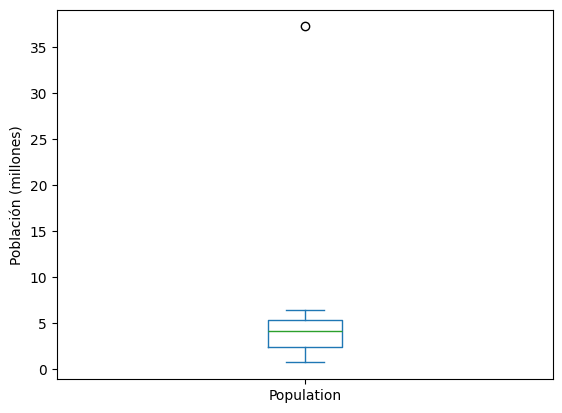

In [ ]:
# Crear el Boxplot
ax = (state['Population']/1000000).plot.box()
ax.set_ylabel('Población (millones)')


### 6.2. Tabla de Frecuencias e Histograma
* **Tabla de frecuecuencias** Organizar los datos con una cantidad de intervalos.


In [8]:
# Tabla de frecuencias
binnedPopulation = pd.cut(state['Population'], 5)

binnedPopulation.value_counts()

,count
Population,
"(673687.275, 8018976.0]",7
"(29945211.0, 37253956.0]",1
"(8018976.0, 15327721.0]",0
"(15327721.0, 22636466.0]",0
"(22636466.0, 29945211.0]",0


Text(0.5, 0, 'Población en Millones')

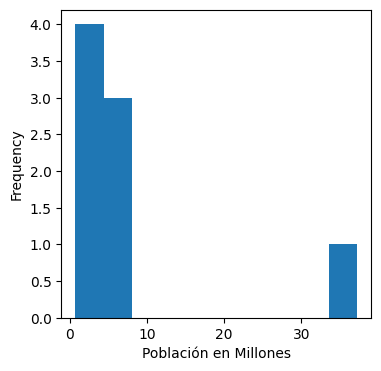

In [9]:
# Histograma
ax = (state['Population'] / 1000000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Población en Millones')

### 6.3. Diagrama de curva de densidad
* Es una representación de la distribución de datos de manera continua

Text(0.5, 0, 'Tasa de Homicidios (por 100,000)')

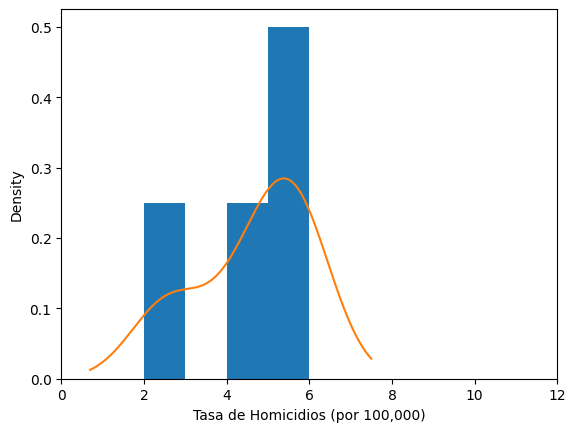

In [10]:
# Curva de densidad
ax = state['Murder rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
state['Murder rate'].plot.density(ax=ax)
ax.set_xlabel('Tasa de Homicidios (por 100,000)')

# 7. Exploración de datos categóricos


Text(0, 0.5, 'Count')

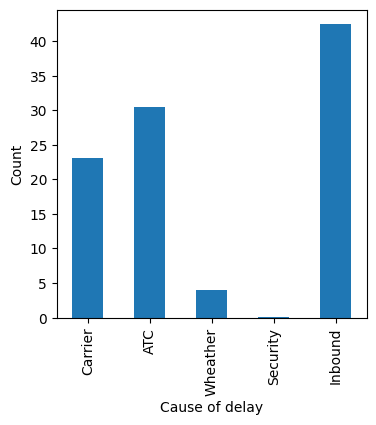

In [11]:
# Datos
data = {
    "Carrier": [23.02],
    "ATC": [30.40],
    "Wheather": [4.03],
    "Security": [0.12],
    "Inbound": [42.43]
}

# Crear el dataframe
dfw = pd.DataFrame(data)

# Grafico de barras para datos categoricos
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')